# BoxCar Ridesharing Discrete-Event Simulation Study — Squareshire

## Introduction

BoxCar are a ride-sharing company in Squareshire (a 20×20 mile square region), operating using a company developed application to match available taxis (drivers) with customers (riders).

The goal of this project is to evaluate BoxCar's system performance through rider and driver satisfaction, and to propose improvements. 

We evaluate rider satisfaction in this report through the metrics: 1. number of rider abandonments due to driver unavailability; and 2. rider waiting times for pick-ups. 
And driver satisfaction through the metrics: 1. average earnings per hour; 2. fairness among drivers; and 3. sufficient rest time

Through extensive discussion with BoxCar executives, we have an outline of the underlying statistical assumptions that the company believes the system follows. Furthermore, we have a 1000 hour cut of company operational data, running from 13:00 01/12/2025 until approximately 24:00 11-01-2026.

 A note of caution regarding testing BoxCar's system assumptions: we have one cut of data that happens to run over the festive period. It is conceivable that both driver and rider behaviour could be be seasonal, and therefore we could be trying to test sound, representative assumptions against a possibly known period of atypical behaviour. We do not have clear direction from BoxCar regarding this concern. In the event that BoxCar's assumptions are not supported by this cut of the data, we intend to model firstly BoxCar's assumptions, then secondly a set of assumptions derived from the cut of data. Moreover, any improvements we suggest will again be tested against both sets of assumptions.

The analysis in this report is structured as follows:

1. **Input Data Analysis** — We test how BoxCar's underlying system assumptions match up against the provided driver and rider datasets
2. **Simulation Model** — We implement a full discrete-event simulation of the Boxcar ride-sharing system operating in Squareshire 
3. **Baseline vs Calibrated Scenarios** — Comparing simulation model performance using BoxCar's assumed parameters against data-driven ones
4. **Improvement Proposals** — Testing interventions to improve rider and driver satisfaction
5. **Conclusions and Recommendations**



In [456]:
import heapq
import random
import math
import statistics
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast
from scipy import stats

---
# Part 1: Input Data Analysis

We examine the provided datasets to validate BoxCar's assumptions and calibrate the simulation parameters. All hypothesis testing reported is performed at the 95% significance level.


## 1.1 Driver Data

In [457]:
df_driver = pd.read_excel("drivers.xlsx")
#print(f"Driver records: {len(df_driver)}")
#df_driver.head()

### Driver Inter-Arrival Times

BoxCar assumption, $H_0$: the drivers make themselves available in the app at random times with an inter-arrival of exponential(3/hour)

$H_a$: driver's do not make themselves available in the app with an inter-arrival time of exponential(3/hour)

We performed a Chi-squared goodness of fit test, resulting in a test statistics T = 740.9309, where T~$\chi^2_{24}$, with P(T>740.9309) < 0.001. Therefore on the evidence of the sample data we would have to reject the null hypothesis, i.e. Boxcar's assumption.

The sample data looked broadly consistent with an exponential distribution, so we estimated the rate parameter and repeated our test.

$H_0$: the drivers make themselves available in the app at random times with an inter-arrival of exponential(4.74/hour)

$H_a$: driver's do not make themselves available in the app with an inter-arrival time of exponential(4.74/hour)

Again, we performed a Chi-squared goodness of fit test, resulting in a test statistic T = 30.79072, where T~$\chi^2_{23}$, with P(T>30.79072) = 0.128022. Therefore, we do not have the evidence to reject the null hypothesis that drivers make themselves available in the app with an inter-arrival of exponential(4.74/hour)

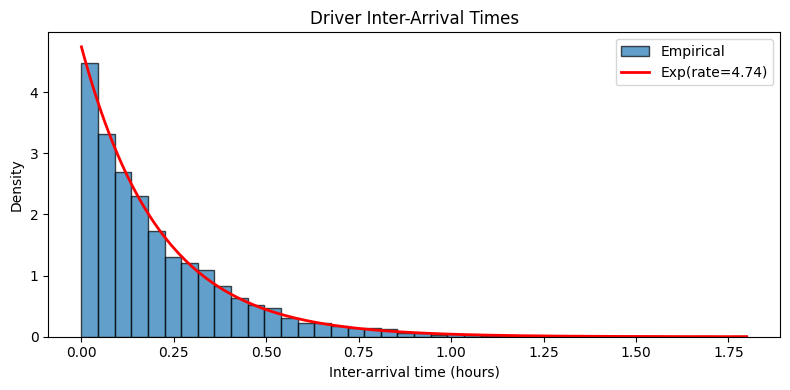

In [458]:
df_d_sorted = df_driver.sort_values("arrival_time")
driver_ia = df_d_sorted["arrival_time"].diff().dropna()
driver_ia_mean = driver_ia.mean()

#print(f"Mean inter-arrival: {driver_ia_mean:.4f} hrs ({driver_ia_mean*60:.1f} min)")
#print(f"Empirical rate: {1/driver_ia_mean:.2f} drivers/hr (spec assumes 3/hr)")

plt.figure(figsize=(8, 4))
plt.hist(driver_ia, bins=40, edgecolor="black", alpha=0.7, density=True, label="Empirical")
from scipy.stats import expon
x = np.linspace(0, driver_ia.max(), 200)
plt.plot(x, expon.pdf(x, scale=driver_ia_mean), "r-", lw=2, label=f"Exp(rate={1/driver_ia_mean:.2f})")
plt.xlabel("Inter-arrival time (hours)")
plt.ylabel("Density")
plt.title("Driver Inter-Arrival Times")
plt.legend()
plt.tight_layout()
plt.show()

### Driver Shift Lengths

BoxCar assumption: Once a driver becomes available, the driver stays available for a random time which is uniformly distributed between 5 and 8 hours and then goes offline.

Examining the sample data, it looks instead that drivers stay available for a uniform random time between 6 and 8 hours.

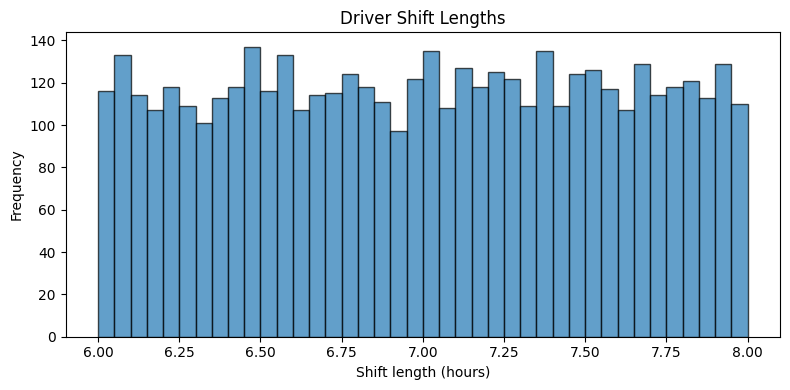

In [459]:
df_driver["shift_length"] = df_driver["offline_time"] - df_driver["arrival_time"]

#print(f"Min shift: {df_driver['shift_length'].min():.2f} hrs")
#print(f"Max shift: {df_driver['shift_length'].max():.2f} hrs")
#print(f"Mean shift: {df_driver['shift_length'].mean():.2f} hrs")

plt.figure(figsize=(8, 4))
plt.hist(df_driver["shift_length"], bins=40, edgecolor="black", alpha=0.7)
plt.xlabel("Shift length (hours)")
plt.ylabel("Frequency")
plt.title("Driver Shift Lengths")
plt.tight_layout()
plt.show()

$H_0$: the drivers' shift lengths follow a uniform(6, 8) distribution

$H_a$: the drivers' shift lengths do not follow a uniform(6, 8) distribution

Again, we performed a Chi-squared goodness of fit test, resulting in a test statistic T = 10.871, where T~$\chi^2_{18}$, with P(T>30.79072) = 0.8997613. Therefore, we do not have the evidence to reject the null hypothesis that drivers' shift lengths follow a uniform(6, 8) distribution.

### Driver Location

BoxCar assumption: the location where a driver becomes available is equally likely to be anywhere in Squareshire, i.e follows a uniform distribution.

$H_0$: Drivers' initial locations follow a uniform distribution across Squareshire

$H_a$: Drivers' initial locations are not uniformly distributed across Squareshire

We split Squareshire into a 20x20 grid, and performed a Chi-squared goodness of fit test, resulting in a test statistic T = 3029.676, where T~$\chi^2+{361}$, with P(T>3029.676) < 0.001. Therefore, on the evidence of the sample data we would reject the null hypothesis, i.e. BoxCar's assumption.

On examining the data, the driver initial x and y coordinates look normally distributed, but are obviously truncated. For the simulation, we decided to fit a (non-truncated) bivariate normal distribution, by sample moments, resulting in a $N_{2}(\mu, \Sigma)$ distribution, with $\mu$ = [9.97391884 11.51331376] and $\Sigma$ = [[19.0502075  0] [0  18.8030244]], and reject the point if it fell outside of the service square.


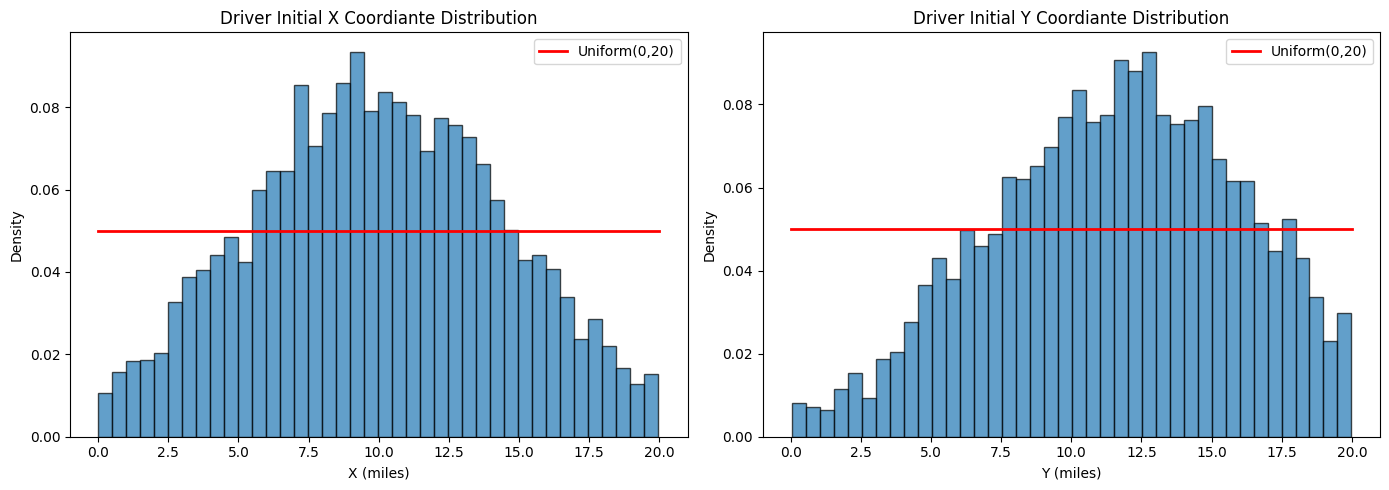

In [460]:
def parse_location(loc_str):
    if pd.isna(loc_str):
        return None, None
    coords = loc_str.strip('()').split(',')
    return float(coords[0]), float(coords[1])

df_driver['init_x'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[0])
df_driver['init_y'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[1])

x = df_driver['init_x'].dropna()
y = df_driver['init_y'].dropna()

fig, axs = plt.subplots(1,2, figsize=(14,5))

axs[0].hist(x,bins=40,density=True,alpha=0.7,edgecolor='black')
xx = np.linspace(0,20,200)
axs[0].plot(xx, stats.uniform.pdf(xx,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[0].set_title('Driver Initial X Coordiante Distribution')
axs[0].set_xlabel('X (miles)')
axs[0].set_ylabel('Density')
axs[0].legend()

axs[1].hist(y,bins=40,density=True,alpha=0.7,edgecolor='black')
yy = np.linspace(0,20,200)
axs[1].plot(yy, stats.uniform.pdf(yy,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[1].set_title('Driver Initial Y Coordiante Distribution')
axs[1].set_xlabel('Y (miles)')
axs[1].set_ylabel('Density')
axs[1].legend()

plt.tight_layout()
plt.show()

In [461]:
#print(df_driver["status"].value_counts())
#print()
#print(df_driver["status"].value_counts(normalize=True).round(4))

## 1.2 Rider Data

In [462]:
df_rider = pd.read_excel("riders.xlsx")
#print(f"Rider records: {len(df_rider)}")
#df_rider.head()

### Rider Inter-Arrival Times


BoxCar assumption, $H_0$: the riders arrive at random times to demand a taxi ride with an inter-arrival time of exponential(30/hour)

$H_a$: riders' inter-arrival times do not follow an exponential(30/hour) distribution

We performed a Kolmogorov-Smirnov test, with critical value 1.480, resulting in a test statistics T = 9.94. Therefore on the evidence of the sample data we would have to reject the null hypothesis, i.e. Boxcar's assumption.

The sample data looked broadly consistent with an exponential distribution, so we estimated the rate parameter and repeated our test.

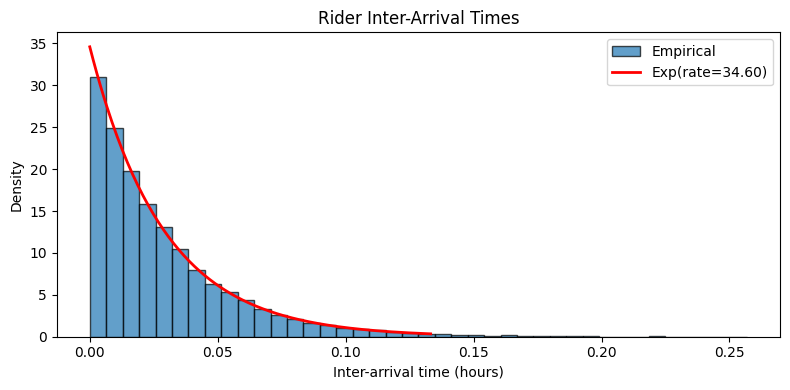

In [463]:
df_r_sorted = df_rider.sort_values("request_time")
rider_ia = df_r_sorted["request_time"].diff().dropna()
rider_ia_mean = rider_ia.mean()

#print(f"Mean inter-arrival: {rider_ia_mean:.4f} hrs ({rider_ia_mean*60:.1f} min)")
#print(f"Empirical rate: {1/rider_ia_mean:.2f} riders/hr (spec assumes 30/hr)")

plt.figure(figsize=(8, 4))
plt.hist(rider_ia, bins=40, edgecolor="black", alpha=0.7, density=True, label="Empirical")
x = np.linspace(0, rider_ia.quantile(0.99), 200)
plt.plot(x, expon.pdf(x, scale=rider_ia_mean), "r-", lw=2, label=f"Exp(rate={1/rider_ia_mean:.2f})")
plt.xlabel("Inter-arrival time (hours)")
plt.ylabel("Density")
plt.title("Rider Inter-Arrival Times")
plt.legend()
plt.tight_layout()
plt.show()

$H_0$: the drivers make themselves available in the app at random times with an inter-arrival of exponential(4.74/hour)

$H_a$: driver's do not make themselves available in the app with an inter-arrival time of exponential(4.74/hour)

Again, we performed a Kolmogorov-Smirnov test, this time with critical value 1.190, resulting in a test statistic T = 0.433. Therefore, we do not have the evidence to reject the null hypothesis that drivers make themselves available in the app with an inter-arrival of exponential(4.74/hour)

### Rider pickup and dropoff locations

BoxCar assumption, $H_0$: rider pickup and dropoff locations are independent of each other and uniformly distributed over Squareshire
$H_a$: rider pickup and dropoff locations are either not independent or not uniformly distributed over Squareshire

We performed a serial test, having first divided Squareshire into a 5x5 grid for pickup locations and a 5x5 grid for dropoff locations, thereby giving 625 possible pickup x dropoff location combinations; resulting in a test statistics T = 58059.15, T~$\chi^2_{624}$, with P(T>58059.15) < 0.00001. Therefore, on the evidence of the sample data we would have to reject the null hypothesis, i.e. BoxCar's assumption.

Looking at the sample data, riders' pickup x coordinates, pickup y coordinates, dropoff x coordinates and dropoff y coordinates all look broadly normally distrubuted, but truncated. We tested the correlation of the four combinations of pickup/dropoff x and y coordinates.

Between drivers' pickup and dropoff x coordinates, T = -0.8979196, T~$t_{34419}$, with P(|T| > 0.8979196) = 0.3692347.

Between drivers' pickup and dropoff y coordinates, T = -1.287377, T~$t_{34419}$, with P(|T| > 1.287377) = 0.1979716.

Between drivers' pickup x coordinates and dropoff y coordinates, T = 1.203628, T~$t_{34419}$, with P(|T| > 1.203628) = 0.2287417.

Between drivers' pickup y coordinates and dropoff x coordinates, T = 0.4404503, T~$t_{34419}$, with P(|T| > 0.4404503) = 0.6596138.

Therefore, from the sample data, it appears that rider pickup and dropoff locations are independent, and can thereby be estimated separately.

For the simulation, for rider pickup and dropoff locations, we decided to fit a (non-truncated) bivariate normal distribution, by sample moments. 
Resulting in a $N_{2}(\mu, \Sigma)$ distirbution for pickup locations, with $\mu$ = [ 8.35968618 12.31754869] and $\Sigma$ = [[18.12253098  2.47169801] [ 2.47169801 17.55955499]], and a $N_{2}(\mu, \Sigma)$ distribution for dropoff locations, with $\mu$ = [11.22966234 13.26257015] and $\Sigma$ =  [[20.6026483   2.20583431] [ 2.20583431 17.38054007]]. Again, we  rejected the point if it fell outside the service square.

In [464]:
#print("Rider status distribution:")
#print(df_rider["status"].value_counts())
#print()

n_abandoned = (df_rider["status"] == "abandoned").sum()
#print(f"Abandonment rate: {n_abandoned}/{len(df_rider)} = {100*n_abandoned/len(df_rider):.2f}%")

# Waiting times for successfully picked-up riders
picked = df_rider[df_rider["pickup_time"].notna() & 
                  (df_rider["pickup_time"] >= df_rider["request_time"])].copy()
picked["wait"] = picked["pickup_time"] - picked["request_time"]

#print(f"Avg waiting time (picked-up): {picked['wait'].mean():.4f} hrs = {picked['wait'].mean()*60:.1f} min")
#print(f"Median waiting time: {picked['wait'].median():.4f} hrs = {picked['wait'].median()*60:.1f} min")

#plt.figure(figsize=(8, 4))
#plt.hist(picked["wait"]*60, bins=50, edgecolor="black", alpha=0.7)
#plt.xlabel("Waiting time (minutes)")
#plt.ylabel("Frequency")
#plt.title("Rider Waiting Times (Request to Pickup)")
#plt.tight_layout()
#plt.show()

In [465]:
def parse_point(s):
    return ast.literal_eval(s)

def euclidean(p1, p2):
    return math.sqrt((p1[0]-p2[0])**2 + (p1[1]-p2[1])**2)

tripped = picked[picked["dropoff_time"].notna() & 
                 (picked["dropoff_time"] >= picked["pickup_time"])].copy()
tripped["trip_dur"] = tripped["dropoff_time"] - tripped["pickup_time"]
tripped["pickup_loc"] = tripped["pickup_location"].map(parse_point)
tripped["dropoff_loc"] = tripped["dropoff_location"].map(parse_point)
tripped["trip_dist"] = [euclidean(p, d) for p, d in 
                         zip(tripped["pickup_loc"], tripped["dropoff_loc"])]

#print(f"Avg trip duration: {tripped['trip_dur'].mean():.4f} hrs = {tripped['trip_dur'].mean()*60:.1f} min")
#print(f"Avg trip distance: {tripped['trip_dist'].mean():.2f} miles")

#fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#axes[0].hist(tripped["trip_dur"]*60, bins=40, edgecolor="black", alpha=0.7)
#axes[0].set_xlabel("Trip duration (minutes)")
#axes[0].set_title("Trip Durations")

#axes[1].hist(tripped["trip_dist"], bins=40, edgecolor="black", alpha=0.7)
#axes[1].set_xlabel("Trip distance (miles)")
#axes[1].set_title("Trip Distances")
#plt.tight_layout()
#plt.show()

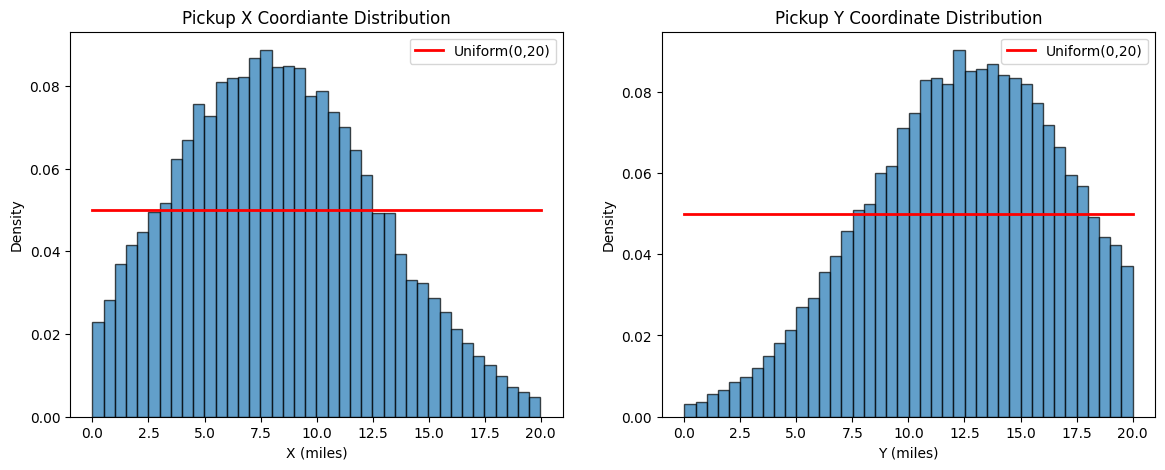

In [466]:
def parse_location(loc_str):
    if pd.isna(loc_str):
        return None, None
    coords = loc_str.strip('()').split(',')
    return float(coords[0]), float(coords[1])

df_rider['pickup_x'] = df_rider['pickup_location'].apply(lambda x: parse_location(x)[0])
df_rider['pickup_y'] = df_rider['pickup_location'].apply(lambda x: parse_location(x)[1])
df_rider['dropoff_x'] = df_rider['dropoff_location'].apply(lambda x: parse_location(x)[0])
df_rider['dropoff_y'] = df_rider['dropoff_location'].apply(lambda x: parse_location(x)[1])
df_driver['init_x'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[0])
df_driver['init_y'] = df_driver['initial_location'].apply(lambda x: parse_location(x)[1])



x = df_rider['pickup_x'].dropna()
y = df_rider['pickup_y'].dropna()

fig, axs = plt.subplots(1,2, figsize=(14,5))

axs[0].hist(x,bins=40,density=True,alpha=0.7,edgecolor='black')
xx = np.linspace(0,20,200)
axs[0].plot(xx, stats.uniform.pdf(xx,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[0].set_title('Pickup X Coordiante Distribution')
axs[0].set_xlabel('X (miles)')
axs[0].set_ylabel('Density')
axs[0].legend()

axs[1].hist(y,bins=40,density=True,alpha=0.7,edgecolor='black')
yy = np.linspace(0,20,200)
axs[1].plot(yy, stats.uniform.pdf(yy,loc=0,scale=20),
           'r-', linewidth=2, label='Uniform(0,20)')
axs[1].set_title('Pickup Y Coordinate Distribution')
axs[1].set_xlabel('Y (miles)')
axs[1].set_ylabel('Density')
axs[1].legend()

#plt.tight_layout()
#plt.show()

### Trip Distances and Durations

BoxCar assumption: The length of a trip depends on the Euclidean distance between points, d. It is assumed that the average speed is approximately 20mph and the actual trip time is uniformly distributed between (0.8*d/20, 1.2*d/20)

We examined the scalar, actual trip time / (d/20), in the sample data and discovered that it took values (0.7, 1.3), implying that actual trip time in the sample data cannot be perturbed by a uniform(0.8, 1.2) random variable. We performed a chi-squared test to see if the scalar followed a uniform(0.7, 1.3) distribution.

$H_0$: actual trip time follows a uniform(0.7*d/20, 1.3*d/20) distribution
$H_a$: actual trip time does not follow a uniform(0.7*d/20, 1.3*d/20) distribution

Out test statistic T = 31.23642, T~$\chi^2_{29}$, with P(T>31.23632) = 0.3543648. Therefore, we do not have the evidence from the sample data to reject the null hypothesis that actual trip time follows a uniform(0.7*d/20, 1.3*d/20) distribution.

In [467]:
# now estimating what eh multivariate normal this thingy is 

data = df_rider[['pickup_x', 'pickup_y']].dropna().values

mu = data.mean(axis=0)

Sigma = np.cov(data.T)
#print(mu)
#print(Sigma)

In [468]:
# so weve got this normal looking thing truncated to [0,20] => do rejection sampling to simulate points people request from (will do the same thing later with dropoff locs)
def sample_trunc_mvnorm_fast(mu, Sigma, n, low=0.0, high=20.0, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    mu = np.asarray(mu)
    Sigma = np.asarray(Sigma)

    # Use acceptance estimate to choose a sensible batch size
    z0 = rng.multivariate_normal(mu, Sigma, size=20000)
    acc = np.mean((z0[:,0]>=low)&(z0[:,0]<=high)&(z0[:,1]>=low)&(z0[:,1]<=high))
    acc = max(acc, 1e-3)
    batch = int(np.ceil(n / acc * 1.1))  # 10% cushion

    out = rng.multivariate_normal(mu, Sigma, size=batch)
    ok = (
        (out[:,0]>=low)&(out[:,0]<=high)&
        (out[:,1]>=low)&(out[:,1]<=high)
    )
    out = out[ok]

    # If we still didn't get enough (rare if acc is stable), top up in batches
    while out.shape[0] < n:
        need = n - out.shape[0]
        batch = int(np.ceil(need / acc * 1.1))
        z = rng.multivariate_normal(mu, Sigma, size=batch)
        ok = (
            (z[:,0]>=low)&(z[:,0]<=high)&
            (z[:,1]>=low)&(z[:,1]<=high)
        )
        out = np.vstack([out, z[ok]])

    return out[:n]

samples = sample_trunc_mvnorm_fast(mu, Sigma, n=35000, low=0, high=20)


In [469]:
z = np.random.multivariate_normal(mu, Sigma, size=20000)
acc = np.mean((z[:,0]>=0)&(z[:,0]<=20)&(z[:,1]>=0)&(z[:,1]<=20))
#print("Acceptance rate:", acc) # good to know so we can see that the rejection sampler isnt terribly inefficient
#print(samples) 

In [470]:
#observed = df_rider[['pickup_x','pickup_y']].dropna().values
#simulated = samples  # from your truncated normal sampler

#fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Observed
#axes[0].scatter(observed[:,0], observed[:,1], s=3, alpha=0.1)
#axes[0].set_title("Observed Pickup Locations")
#axes[0].set_xlim(0,20)
#axes[0].set_ylim(0,20)

# Simulated
#axes[1].scatter(simulated[:,0], simulated[:,1], s=3, alpha=0.1, color='orange')
#axes[1].set_title("Simulated Truncated Normal")
#axes[1].set_xlim(0,20)
#axes[1].set_ylim(0,20)

#plt.tight_layout()
#plt.show()
#observed.shape

In [471]:
def fit_mvnorm(points_2d):
    """Fit a (non-truncated) bivariate normal by sample moments.
    For simulation we will *sample then reject* outside the service square to emulate truncation.
    points_2d: array of shape (n,2)
    """
    mu = points_2d.mean(axis=0)
    Sigma = np.cov(points_2d.T) 
    return mu, Sigma

# Fit from observed data
pickup_pts  = df_rider[['pickup_x','pickup_y']].dropna().values
dropoff_pts = df_rider[['dropoff_x','dropoff_y']].dropna().values

driver_initial_pts = df_driver[['init_x', 'init_y']].dropna().values

mu_pick,  Sig_pick  = fit_mvnorm(pickup_pts)
mu_drop,  Sig_drop  = fit_mvnorm(dropoff_pts)
mu_driver, Sig_driver = fit_mvnorm(driver_initial_pts)

#print("Pickup fit  mu:", mu_pick)
#print("Pickup fit  Sigma:\n", Sig_pick)
#print("Dropoff fit mu:", mu_drop)
#print("Dropoff fit Sigma:\n", Sig_drop)
#print("Driver fit mu:", mu_driver)
#print("Driver fit Sigma:\n", Sig_driver)


## 1.3 Summary of Data vs Spec Parameters

| Parameter | BoxCar Assumption | Empirical (Data) |
|---|---|---|
| Driver arrival rate | 3/hr | **4.74/hr** |
| Driver shift length | U[5, 8] hrs | **U[6, 8] hrs** |
| Driver initial location | Uniform | Truncated Bivariate Normal |
| Rider arrival rate | 30/hr | **34.6/hr** |
| Rider locations | Uniform | Truncated Bivariate Normal |
| Rider patience | Exp(5/hr) | ~0.81% abandon (consistent) |
| Avg trip distance | ~9.4 mi (theory for 20×20) | **8.16 mi** |
| Avg waiting time | — | **14.2 min** |
| Actual trip duration perturbation | Uniform(0.8, 1.2) | Uniform(0.7, 1.3)|

---
# Part 2: Simulation Model

We implement a discrete-event simulation engine with the following features:

- **Rider arrivals** with exponential inter-arrival times and exponential patience (abandonment if unmatched)
- **Driver arrivals** with exponential inter-arrival and uniform shift lengths; drivers go offline after their shift (finishing any current trip first)
- **Closest-idle-driver matching** triggered whenever a new rider arrives or a driver becomes idle
- **Two-phase trips**: pickup travel (driver→origin) then trip travel (origin→destination), both with travel time ~ U[aμ, bμ] where μ = distance/20 mph 
- **Fare**: £3 base + £2/mile (origin→destination); **Fuel**: £0.20/mile for ALL miles driven
- **Warm-up period** to reach steady state, and **multiple replications** for statistical validity

In [472]:
class BoxCarSimulation:
    """
    Discrete-event simulation of the BoxCar ridesharing system.
    Uses a heap-based event list with tiebreaker counter.
    """

    def __init__(self, params, seed=None):
        self.p = params
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self._pool_pick = None
        self._pool_drop = None
        self._pool_drv  = None
        self._k_pick = 0
        self._k_drop = 0
        self._k_drv  = 0

    def run(self):
        """Execute one simulation run. Returns a metrics dict."""
        if self.seed is not None:
            random.seed(self.seed)
            # Keep NumPy RNG in sync for reproducibility
            self.rng = np.random.default_rng(self.seed)

        # State variables
        self.clock = 0.0
        self.event_list = []
        self.event_counter = 0

        self.idle_drivers = []
        self.waiting_riders = []    # list of (rider_dict, patience_deadline)
        self.all_drivers = []

        # Metrics
        self.total_riders = 0
        self.abandonments_list = []  # store times for warm-up-consistent rates
        self.waiting_times = []
        self.driver_records = []

        # Schedule first arrivals
        self._schedule("RIDER_ARRIVAL",
                       self.clock + random.expovariate(self.p["rider_rate"]))
        self._schedule("DRIVER_ARRIVAL",
                       self.clock + random.expovariate(self.p["driver_rate"]))

        # Main loop
        while self.event_list:
            _, _, event = heapq.heappop(self.event_list)
            if event["time"] > self.p["sim_duration"]:
                break
            self.clock = event["time"]

            handler = {
                "RIDER_ARRIVAL":     self._handle_rider_arrival,
                "DRIVER_ARRIVAL":    self._handle_driver_arrival,
                "RIDER_ABANDON":     self._handle_rider_abandon,
                "PICKUP_COMPLETE":   self._handle_pickup_complete,
                "DROPOFF":           self._handle_dropoff,
                "DRIVER_GO_OFFLINE": self._handle_driver_offline,
            }.get(event["type"])

            if handler:
                handler(event)

        return self._compile_metrics(self.p["warm_up"])

    # --- Event scheduling ---

    def _schedule(self, etype, time, data=None):
        self.event_counter += 1
        event = {"type": etype, "time": time, "data": data or {}}
        heapq.heappush(self.event_list, (time, self.event_counter, event))

    # --- Matching logic ---

    def _try_match(self):
        """Match all possible idle-driver / waiting-rider pairs (FIFO rider, closest driver)."""
        matched_any = True
        while matched_any:
            matched_any = False
            # Clean up abandoned riders
            self.waiting_riders = [(r, d) for r, d in self.waiting_riders
                                   if r["status"] == "waiting"]
            if not self.waiting_riders or not self.idle_drivers:
                break

            rider, deadline = self.waiting_riders[0]
            if self.clock > deadline:
                self.waiting_riders.pop(0)
                continue

            if not self.idle_drivers:
                break

            # Find closest idle driver to rider origin
            max_busy_time_idle_drivers = max(range(len(self.idle_drivers)),
                                            key=lambda i: (self.idle_drivers[i]["busy_time"] / (self.clock - self.idle_drivers[i]["arrival_time"] + 0.1)))
                                            
            if self.p["weight_distance_by_utilization"] is True and max_busy_time_idle_drivers > 0.0:
                best_idx = min(range(len(self.idle_drivers)),
                                key=lambda i: ((self.idle_drivers[i]["busy_time"] / (self.clock - self.idle_drivers[i]["arrival_time"] + 0.1)) / max_busy_time_idle_drivers) * self._dist(
                                self.idle_drivers[i]["location"], rider["origin"]))
            else:
                best_idx = min(range(len(self.idle_drivers)),
                                key=lambda i: self._dist(
                                self.idle_drivers[i]["location"], rider["origin"]))
            driver = self.idle_drivers.pop(best_idx)
            self.waiting_riders.pop(0)

            # Update our driver/rider status 
            rider["status"] = "matched"
            driver["status"] = "driving_to_pickup"

            # Compute pickup travel time
            d_pickup = self._dist(driver["location"], rider["origin"])
            mu_pickup = d_pickup / self.p["speed"]
            pickup_time = random.uniform(self.p["trip_scalar_min"] * mu_pickup, self.p["trip_scalar_max"] * mu_pickup) if mu_pickup > 0 else 0.0

            rider["match_time"] = self.clock
            rider["pickup_distance"] = d_pickup

            self._schedule("PICKUP_COMPLETE", self.clock + pickup_time,
                           {"rider": rider, "driver": driver})
            matched_any = True

    # --- Event handlers ---

    # rider arrives in system and makes a ride request
    def _handle_rider_arrival(self, event):
        self.total_riders += 1
        R = self.p["region_size"]

        rider = {
            "id": self.total_riders,
            "arrival_time": self.clock,
            "origin": self._draw_pickup(),
            "destination": self._draw_dropoff(),
            "status": "waiting",
            "match_time": None,
            "pickup_distance": 0,
        }

        # Schedule patience timeout
        patience = random.expovariate(self.p["patience_rate"])
        deadline = self.clock + patience
        self.waiting_riders.append((rider, deadline))
        self._schedule("RIDER_ABANDON", deadline, {"rider": rider})

        # Schedule next rider
        self._schedule("RIDER_ARRIVAL",
                       self.clock + random.expovariate(self.p["rider_rate"]))

        self._try_match()

    def _handle_rider_abandon(self, event):
        rider = event["data"]["rider"]
        if rider["status"] == "waiting":
            rider["status"] = "abandoned"
            self.abandonments_list.append(self.clock)

    # Simulate initial point where the driver begins their shift, and initialise metrics
    def _handle_driver_arrival(self, event):
        R = self.p["region_size"]

        driver = {
            "id": len(self.all_drivers) + 1,
            "arrival_time": self.clock,
            "location": self._draw_driver_loc(),
            "status": "idle",
            "earnings": 0.0,
            "fuel_cost": 0.0,
            "trips_completed": 0,
            "total_miles": 0.0,
            "busy_time": 0.0,
        }

        # Schedule offline time
        shift = random.uniform(self.p["shift_min"], self.p["shift_max"])
        driver["offline_deadline"] = self.clock + shift
        self._schedule("DRIVER_GO_OFFLINE", driver["offline_deadline"],
                       {"driver": driver})

        self.all_drivers.append(driver)
        self.idle_drivers.append(driver)

        # Schedule next driver
        self._schedule("DRIVER_ARRIVAL",
                       self.clock + random.expovariate(self.p["driver_rate"]))

        self._try_match()

    # Event where the taxi arrives at the pickup location
    def _handle_pickup_complete(self, event):
        rider = event["data"]["rider"]
        driver = event["data"]["driver"]

        # Record waiting time (request -> pickup)
        wait = self.clock - rider["arrival_time"]
        self.waiting_times.append((rider["arrival_time"], wait))

        # Driver moves to rider origin
        driver["location"] = rider["origin"]

        # Fuel for pickup leg
        d_pickup = rider["pickup_distance"]
        driver["fuel_cost"] += self.p["fuel_per_mile"] * d_pickup
        driver["total_miles"] += d_pickup

        # Compute trip to destination
        d_trip = self._dist(rider["origin"], rider["destination"])
        mu_trip = d_trip / self.p["speed"]
        trip_time = random.uniform(self.p["trip_scalar_min"] * mu_trip, self.p["trip_scalar_max"] * mu_trip) if mu_trip > 0 else 0.0

        rider["status"] = "in_trip"
        driver["status"] = "in_trip"

        self._schedule("DROPOFF", self.clock + trip_time,
                       {"rider": rider, "driver": driver,
                        "trip_distance": d_trip,
                        "pickup_start": rider["match_time"]})

    # Event where the rider reaches their destination
    def _handle_dropoff(self, event):
        rider = event["data"]["rider"]
        driver = event["data"]["driver"]
        d_trip = event["data"]["trip_distance"]
        pickup_start = event["data"]["pickup_start"]

        rider["status"] = "dropped_off"

        # Fare and costs
        fare = self.p["base_fare"] + self.p["per_mile_fare"] * d_trip
        fuel_trip = self.p["fuel_per_mile"] * d_trip

        driver["earnings"] += fare
        driver["fuel_cost"] += fuel_trip
        driver["total_miles"] += d_trip
        driver["trips_completed"] += 1
        driver["location"] = rider["destination"]

        if pickup_start is not None:
            driver["busy_time"] += (self.clock - pickup_start)

        # Check if driver should go offline at this point
        if self.clock >= driver["offline_deadline"]:
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock
        else:
            driver["status"] = "idle"
            self.idle_drivers.append(driver)
            self._try_match()

    # Dealing with event that driver shift ends 
    def _handle_driver_offline(self, event):
        driver = event["data"]["driver"]
        if driver["status"] == "idle":
            if driver in self.idle_drivers:
                self.idle_drivers.remove(driver)
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock
        elif driver["status"] in ("driving_to_pickup", "in_trip"):
            pass  # Will go offline after finishing current trip (checked in dropoff)
        else:
            driver["status"] = "offline"
            driver["actual_offline"] = self.clock

    # --- Utilities ---

    # Simulating rider original point 
    def _draw_pickup(self):
        R = self.p["region_size"]
        if not self.p.get("calibrated_spatial", False):
            return (random.uniform(0, R), random.uniform(0, R))

        if self._pool_pick is None or self._k_pick >= len(self._pool_pick):
            self._pool_pick = sample_trunc_mvnorm_fast(
                self.p["mu_pick"], self.p["Sig_pick"],
                n=50000, low=0.0, high=R, rng=self.rng
            )
            self._k_pick = 0 
        
        pt = self._pool_pick[self._k_pick]
        self._k_pick += 1
        return (float(pt[0]), float(pt[1]))

    # Simulating a point where the rider wants to go to 
    def _draw_dropoff(self):
        R = self.p["region_size"]
        if not self.p.get("calibrated_spatial", False):
            return (random.uniform(0, R), random.uniform(0, R))

        if self._pool_drop is None or self._k_drop >= len(self._pool_drop):
            self._pool_drop = sample_trunc_mvnorm_fast(
                self.p["mu_drop"], self.p["Sig_drop"],
                n=50000, low=0.0, high=R, rng=self.rng
            )
            self._k_drop = 0

        pt = self._pool_drop[self._k_drop]
        self._k_drop += 1
        return (float(pt[0]), float(pt[1]))

    # Simuating a point where the driver begins their shift from 
    def _draw_driver_loc(self):
        R = self.p["region_size"]
        if not self.p.get("calibrated_spatial", False):
            return (random.uniform(0,R), random.uniform(0,R))

        mu = self.p.get("mu_driver", self.p["mu_pick"])
        Sig = self.p.get("Sig_driver", self.p["Sig_pick"])

        if self._pool_drv is None or self._k_drv >= len(self._pool_drv):
            self._pool_drv = sample_trunc_mvnorm_fast(
                mu, Sig, n=10000, low=0.0, high=R, rng=self.rng
            )
            self._k_drv = 0

        pt = self._pool_drv[self._k_drv]
        self._k_drv += 1
        return (float(pt[0]), float(pt[1]))

    @staticmethod
    def _dist(p1, p2):
        return math.sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

    def _compile_metrics(self, warm_up):
        wt = [w for (t, w) in self.waiting_times if t >= warm_up]
        ab_post = sum(1 for t in self.abandonments_list if t >= warm_up)

        driver_earnings, driver_net, driver_hourly = [], [], []
        driver_util, driver_trips = [], []

        for d in self.all_drivers:
            if d["arrival_time"] < warm_up:
                continue
            actual_off = d.get("actual_offline", self.p["sim_duration"])
            shift_dur = actual_off - d["arrival_time"]
            if shift_dur <= 0:
                continue

            net = d["earnings"] - d["fuel_cost"]
            driver_earnings.append(d["earnings"])
            driver_net.append(net)
            driver_hourly.append(net / shift_dur)
            driver_util.append(d["busy_time"] / shift_dur)
            driver_trips.append(d["trips_completed"])

        return {
            "avg_wait": statistics.mean(wt) if wt else 0,
            "median_wait": statistics.median(wt) if wt else 0,
            "p90_wait": float(np.percentile(wt, 90)) if wt else 0,
            "total_served": len(wt),
            "total_abandoned": ab_post,
            "abandon_rate": ab_post / (len(wt) + ab_post) if (len(wt) + ab_post) > 0 else 0,
            "avg_gross_earning": statistics.mean(driver_earnings) if driver_earnings else 0,
            "avg_net_earning": statistics.mean(driver_net) if driver_net else 0,
            "avg_hourly_net": statistics.mean(driver_hourly) if driver_hourly else 0,
            "std_hourly_net": statistics.stdev(driver_hourly) if len(driver_hourly) > 1 else 0,
            "avg_utilisation": statistics.mean(driver_util) if driver_util else 0,
            "avg_trips_per_driver": statistics.mean(driver_trips) if driver_trips else 0,
            "num_drivers": len(driver_earnings),
            "waiting_times_raw": wt,
            "driver_hourly_raw": driver_hourly,
        }


def print_metrics(m, label=""):
    print(f"{'='*55}")
    if label:
        print(f"  {label}")
        print(f"{'='*55}")
    print(f"  Riders served:           {m['total_served']}")
    print(f"  Riders abandoned:        {m['total_abandoned']}")
    print(f"  Abandonment rate:        {m['abandon_rate']*100:.2f}%")
    print(f"  Avg wait time:           {m['avg_wait']*60:.1f} min")
    print(f"  Median wait time:        {m['median_wait']*60:.1f} min")
    print(f"  90th pctile wait:        {m['p90_wait']*60:.1f} min")
    print(f"  ---")
    print(f"  Drivers (post warm-up):  {m['num_drivers']}")
    print(f"  Avg gross earning:       £{m['avg_gross_earning']:.2f}")
    print(f"  Avg net earning:         £{m['avg_net_earning']:.2f}")
    print(f"  Avg hourly net:          £{m['avg_hourly_net']:.2f}/hr")
    print(f"  Std hourly net:          £{m['std_hourly_net']:.2f}/hr")
    print(f"  Avg utilisation:         {m['avg_utilisation']*100:.1f}%")
    print(f"  Avg trips/driver:        {m['avg_trips_per_driver']:.1f}")


def average_metrics(results):
    keys = ["avg_wait", "median_wait", "p90_wait", "total_served",
            "total_abandoned", "abandon_rate", "avg_gross_earning",
            "avg_net_earning", "avg_hourly_net", "std_hourly_net",
            "avg_utilisation", "avg_trips_per_driver", "num_drivers"]
    avg = {k: statistics.mean([r[k] for r in results]) for k in keys}
    avg["waiting_times_raw"] = []
    avg["driver_hourly_raw"] = []
    return avg


#print("Simulation engine ready.")

---
## Baseline Scenario 

Using the parameters as described in the project brief: rider rate = 30/hr, driver rate = 3/hr, shift = U[5,8], patience = Exp(5/hr).

In [473]:
baseline_params = {
    "rider_rate": 30, "driver_rate": 3, "patience_rate": 5,
    "shift_min": 5, "shift_max": 8,
    "trip_scalar_min": 0.8, "trip_scalar_max": 1.2,
    "speed": 20, "base_fare": 3, "per_mile_fare": 2,
    "fuel_per_mile": 0.20, "region_size": 20,
    "sim_duration": 200, "warm_up": 24, 
    "weight_distance_by_utilization": False
}

NUM_REPS = 100 # Might want to increase this, 5 isnt necessarily a large number of total simulations 
#print(f"Running {NUM_REPS} replications of {baseline_params['sim_duration']}h ")
#print(f"(warm-up: {baseline_params['warm_up']}h)...")

baseline_results = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(baseline_params, seed=42 + rep)
    m = sim.run()
    baseline_results.append(m)
#    print(f"  Rep {rep+1}: served={m['total_served']}, "
#          f"abandoned={m['total_abandoned']}, "
#          f"avg_wait={m['avg_wait']*60:.1f}min, "
#          f"abandon={m['abandon_rate']*100:.1f}%")

baseline_avg = average_metrics(baseline_results)
#print_metrics(baseline_avg, "BASELINE AVERAGE (BoxCar spec params)")

---
# Data-Calibrated Scenario

Using parameters calibrated from the dataset: rider rate = 34.6/hr, driver rate = 4.74/hr, shift = U[6,8], and the estimated $\mu$ and $\Sigma$ from the gaussianisation

In [474]:
# scenario where i fix the spatial distributions
calib_params = dict(baseline_params)  # copy
calib_params["calibrated_spatial"] = True
calib_params["mu_pick"]  = mu_pick
calib_params["Sig_pick"] = Sig_pick
calib_params["mu_drop"]  = mu_drop
calib_params["Sig_drop"] = Sig_drop
calib_params["mu_driver"] = mu_driver
calib_params["Sig_driver"] = Sig_driver

In [475]:
# Data-calibrated scenario: calibrate rates/shifts to observed data AND use fitted spatial distributions
calibrated_params = dict(baseline_params)
calibrated_params.update({
    "rider_rate": 34.6,      # from data analysis
    "driver_rate": 4.74,     # from data analysis
    "shift_min": 6,
    "shift_max": 8,
    "trip_scalar_min": 0.7,
    "trip_scalar_max": 1.3,
    # spatial calibration (pickups + dropoffs)
    "calibrated_spatial": True,
    "mu_pick":  mu_pick,
    "Sig_pick": Sig_pick,
    "mu_drop":  mu_drop,
    "Sig_drop": Sig_drop,
    "mu_driver": mu_driver,
    "Sig_driver": Sig_driver
})

#print("Key differences from baseline:")
#print(f"  Rider rate: 30 -> {calibrated_params['rider_rate']}/hr")
#print(f"  Driver rate: 3 -> {calibrated_params['driver_rate']}/hr")
#print(f"  Shift range: U[5,8] -> U[{calibrated_params['shift_min']},{calibrated_params['shift_max']}]")
#print("  Spatial: uniform -> truncated bivariate normal (moment-fit + rejection)")


---
# Part 5: Improvement Scenarios

We test three interventions to improve rider satisfaction while monitoring the trade-off with driver earnings:

1. **More drivers** — Increase driver arrival rate to 6/hr
2. **Longer shifts** — Extend shift range to U[7, 10] hours
3. **Combined** — Both interventions together

In [476]:
calibrated_results = []

for rep in range(NUM_REPS):
    sim = BoxCarSimulation(calibrated_params, seed = 42 + rep)
    calibrated_results.append(sim.run())
calibrated_avg = average_metrics(calibrated_results)
#print_metrics(calibrated_avg, "CALIBRATED DATA")

In [477]:
# Improvement 1: More drivers
imp1_params_b = baseline_params.copy()
imp1_params_b["driver_rate"] = 6

imp1_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp1_params_b, seed=42 + rep)
    imp1_results_b.append(sim.run())
imp1_avg_b = average_metrics(imp1_results_b)
#print_metrics(imp1_avg_b, "IMPROVEMENT 1: More drivers (6/hr) - baseline params")


imp1_params_c = calibrated_params.copy()
imp1_params_c["driver_rate"] = 6

imp1_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp1_params_c, seed=42 + rep)
    imp1_results_c.append(sim.run())
imp1_avg_c = average_metrics(imp1_results_c)
#print_metrics(imp1_avg_c, "IMPROVEMENT 1: More drivers (6/hr) - calibrated params")

In [478]:
# Improvement 2: Longer shifts

imp2_params_b = baseline_params.copy()
imp2_params_b["shift_min"] = 7
imp2_params_b["shift_max"] = 10

imp2_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp2_params_b, seed=42 + rep)
    imp2_results_b.append(sim.run())
imp2_avg_b = average_metrics(imp2_results_b)
#print_metrics(imp2_avg_b, "IMPROVEMENT 2: Longer shifts U[7,10] - baseline params")



imp2_params_c = calibrated_params.copy()
imp2_params_c["shift_min"] = 7
imp2_params_c["shift_max"] = 10

imp2_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp2_params_c, seed=42 + rep)
    imp2_results_c.append(sim.run())
imp2_avg_c = average_metrics(imp2_results_c)
#print_metrics(imp2_avg_c, "IMPROVEMENT 2: Longer shifts U[7,10] - calibrated params")

In [479]:
# Improvement 3: Combined

imp3_params_b = baseline_params.copy()
imp3_params_b["driver_rate"] = 6.0
imp3_params_b["shift_min"] = 7
imp3_params_b["shift_max"] = 10
imp3_params_b["weight_distance_by_utilization"] = True

imp3_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp3_params_b, seed=42 + rep)
    imp3_results_b.append(sim.run())
imp3_avg_b = average_metrics(imp3_results_b)
#print_metrics(imp3_avg_b, "IMPROVEMENT 3: Combined - baseline params")


imp3_params_c = calibrated_params.copy()
imp3_params_c["driver_rate"] = 6.0
imp3_params_c["shift_min"] = 7
imp3_params_c["shift_max"] = 10
imp3_params_b["weight_distance_by_utilization"] = True

imp3_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp3_params_c, seed=42 + rep)
    imp3_results_c.append(sim.run())
imp3_avg_c = average_metrics(imp3_results_c)
#print_metrics(imp3_avg_c, "IMPROVEMENT 3: Combined - calibrated params")

In [480]:
# Improvement 4, weight distance by driver utilization
"weight_distance_by_utilization"

imp4_params_b = baseline_params.copy()
imp4_params_b["weight_distance_by_utilization"] = True

imp4_results_b = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp4_params_b, seed=42 + rep)
    imp4_results_b.append(sim.run())
imp4_avg_b = average_metrics(imp4_results_b)


imp4_params_c = calibrated_params.copy()
imp4_params_c["weight_distance_by_utilization"] = True

imp4_results_c = []
for rep in range(NUM_REPS):
    sim = BoxCarSimulation(imp4_params_c, seed=42 + rep)
    imp4_results_c.append(sim.run())
imp4_avg_c = average_metrics(imp4_results_c)

---
# Part 6: Summary Comparison

In [481]:
scenarios_baseline = {
    "Baseline (spec)": baseline_avg,
    "More drivers (6/hr)": imp1_avg_b,
    "Longer shifts U[7,10]": imp2_avg_b,
    "Weighted distance": imp4_avg_b,
    "Combined ": imp3_avg_b
}

header = f"{'Scenario':<24} {'Riders_served':>6} {'Abandon%':>10} {'AvgWait':>10} {'P90Wait':>10} "
print(header)
print("-" * len(header))
for name, m in scenarios_baseline.items():
    print(f"{name:<24}"
          f"    {m['total_served']:>7.2f}  "
          f"   {m['abandon_rate']*100:>7.2f}% "
          f"{m['avg_wait']*60:>9.1f}m "
          f"{m['p90_wait']*60:>9.1f}m "
    )



Scenario                 Riders_served   Abandon%    AvgWait    P90Wait 
------------------------------------------------------------------------
Baseline (spec)             3596.34       31.66%      31.2m      54.7m 
More drivers (6/hr)         5265.88        0.35%       9.8m      19.2m 
Longer shifts U[7,10]       4499.18       14.59%      23.4m      47.4m 
Weighted distance           3544.63       32.57%      32.2m      55.4m 
Combined                    5257.72        0.01%      12.4m      31.8m 


**TEXT describing results**

In [482]:

header = f"{'Scenario':<22}  {'Drivers':>10} {'£/hr net':>10} {'  £/hr net std':>6} {'Util%':>8} {'  Avg Trips / driver':>6}"
print(header)
print("-" * len(header))
for name, m in scenarios_baseline.items():
    print(f"{name:<24}"
          f"{m['num_drivers']:>9.1f}"
          f"  {m['avg_hourly_net']:>9.2f} "
          f"   {m['std_hourly_net']:>9.2f}"
          f"    {m['avg_utilisation']*100:>7.1f}% "
          f"      {m['avg_trips_per_driver']:>5.1f}")

Scenario                   Drivers   £/hr net   £/hr net std    Util%   Avg Trips / driver
------------------------------------------------------------------------------------------
Baseline (spec)             529.8      19.04         3.17       93.9%         6.6
More drivers (6/hr)        1052.7      15.58         5.07       50.5%         4.9
Longer shifts U[7,10]       529.7      19.12         3.25       83.7%         8.3
Weighted distance           526.2      18.82         3.16       94.6%         6.6
Combined                   1055.9      11.92         3.36       41.9%         4.9


**Text describing results**

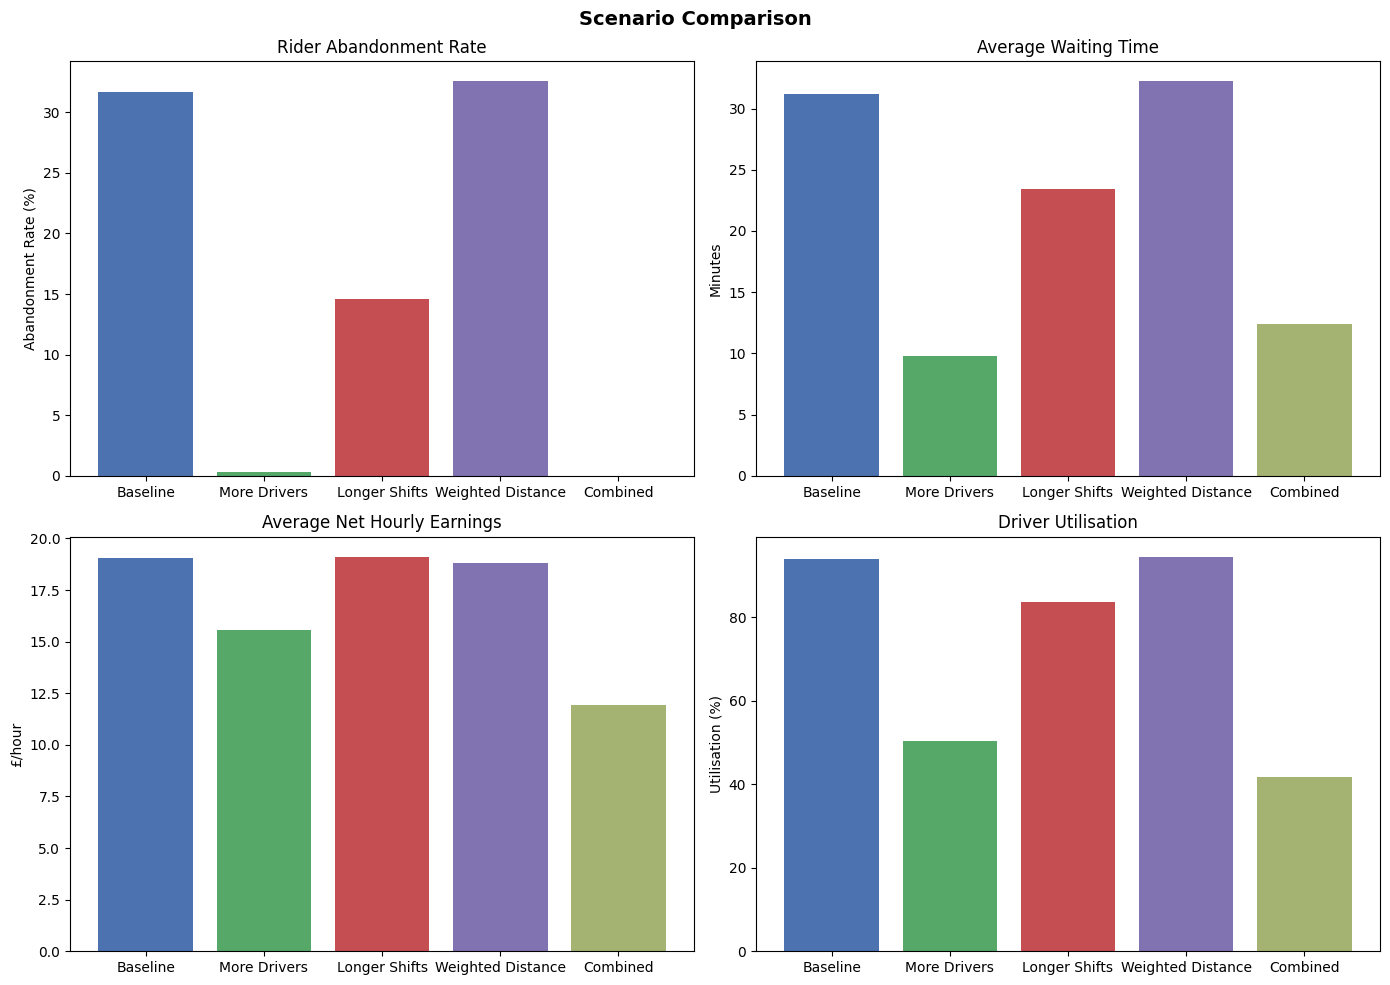

In [483]:
names = list(scenarios_baseline.keys())
short_names = ["Baseline", "More Drivers", "Longer Shifts", "Weighted Distance", "Combined"]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#A4B272"]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Abandonment rate
vals = [scenarios_baseline[n]["abandon_rate"]*100 for n in names]
axes[0,0].bar(short_names, vals, color=colors)
axes[0,0].set_ylabel("Abandonment Rate (%)")
axes[0,0].set_title("Rider Abandonment Rate")

# Average waiting time
vals = [scenarios_baseline[n]["avg_wait"]*60 for n in names]
axes[0,1].bar(short_names, vals, color=colors)
axes[0,1].set_ylabel("Minutes")
axes[0,1].set_title("Average Waiting Time")

# Hourly net earnings
vals = [scenarios_baseline[n]["avg_hourly_net"] for n in names]
axes[1,0].bar(short_names, vals, color=colors)
axes[1,0].set_ylabel("£/hour")
axes[1,0].set_title("Average Net Hourly Earnings")

# Utilisation
vals = [scenarios_baseline[n]["avg_utilisation"]*100 for n in names]
axes[1,1].bar(short_names, vals, color=colors)
axes[1,1].set_ylabel("Utilisation (%)")
axes[1,1].set_title("Driver Utilisation")

plt.suptitle("Scenario Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [484]:
scenarios_calibrated = {
    "Calibrated (data)": calibrated_avg,
    "More drivers (6/hr)": imp1_avg_c,
    "Longer shifts U[7,10]": imp2_avg_c,
    "Weighted Distance": imp4_avg_c,
    "Combined": imp3_avg_c,
}

header = f"{'Scenario':<24} {'Riders_served':>6} {'Abandon%':>10} {'AvgWait':>10} {'P90Wait':>10} "
print(header)
print("-" * len(header))
for name, m in scenarios_calibrated.items():
    print(f"{name:<24}"
          f"    {m['total_served']:>7.2f}  "
          f"   {m['abandon_rate']*100:>7.2f}% "
          f"{m['avg_wait']*60:>9.1f}m "
          f"{m['p90_wait']*60:>9.1f}m "
    )


Scenario                 Riders_served   Abandon%    AvgWait    P90Wait 
------------------------------------------------------------------------
Calibrated (data)           6035.13        0.88%      12.3m      25.3m 
More drivers (6/hr)         6071.89        0.04%      10.3m      21.3m 
Longer shifts U[7,10]       6063.76        0.11%      11.0m      22.6m 
Weighted Distance           6009.66        1.05%      13.9m      29.4m 
Combined                    6079.59        0.00%       9.5m      19.9m 


**TExt describing results**

In [485]:
header = f"{'Scenario':<22}  {'Drivers':>10} {'£/hr net':>10} {'  £/hr net std':>6} {'Util%':>8} {'  Avg Trips / driver':>6}"
print(header)
print("-" * len(header))
for name, m in scenarios_calibrated.items():
    print(f"{name:<24}"
          f" {m['num_drivers']:>9.1f}"
          f" {m['avg_hourly_net']:>9.2f} "
          f" {m['std_hourly_net']:>9.2f}"
          f"      {m['avg_utilisation']*100:>7.1f}% "
          f"      {m['avg_trips_per_driver']:>5.1f}")

Scenario                   Drivers   £/hr net   £/hr net std    Util%   Avg Trips / driver
------------------------------------------------------------------------------------------
Calibrated (data)            837.4     15.31       5.12         56.8%         7.1
More drivers (6/hr)         1053.0     12.50       5.63         43.4%         5.7
Longer shifts U[7,10]        836.5     12.92       5.44         45.9%         7.1
Weighted Distance            833.0     15.22       3.74         59.5%         7.1
Combined                    1058.2     10.40       5.46         35.2%         5.6


**TExt describing results**

---
# Part 7: Visualisations

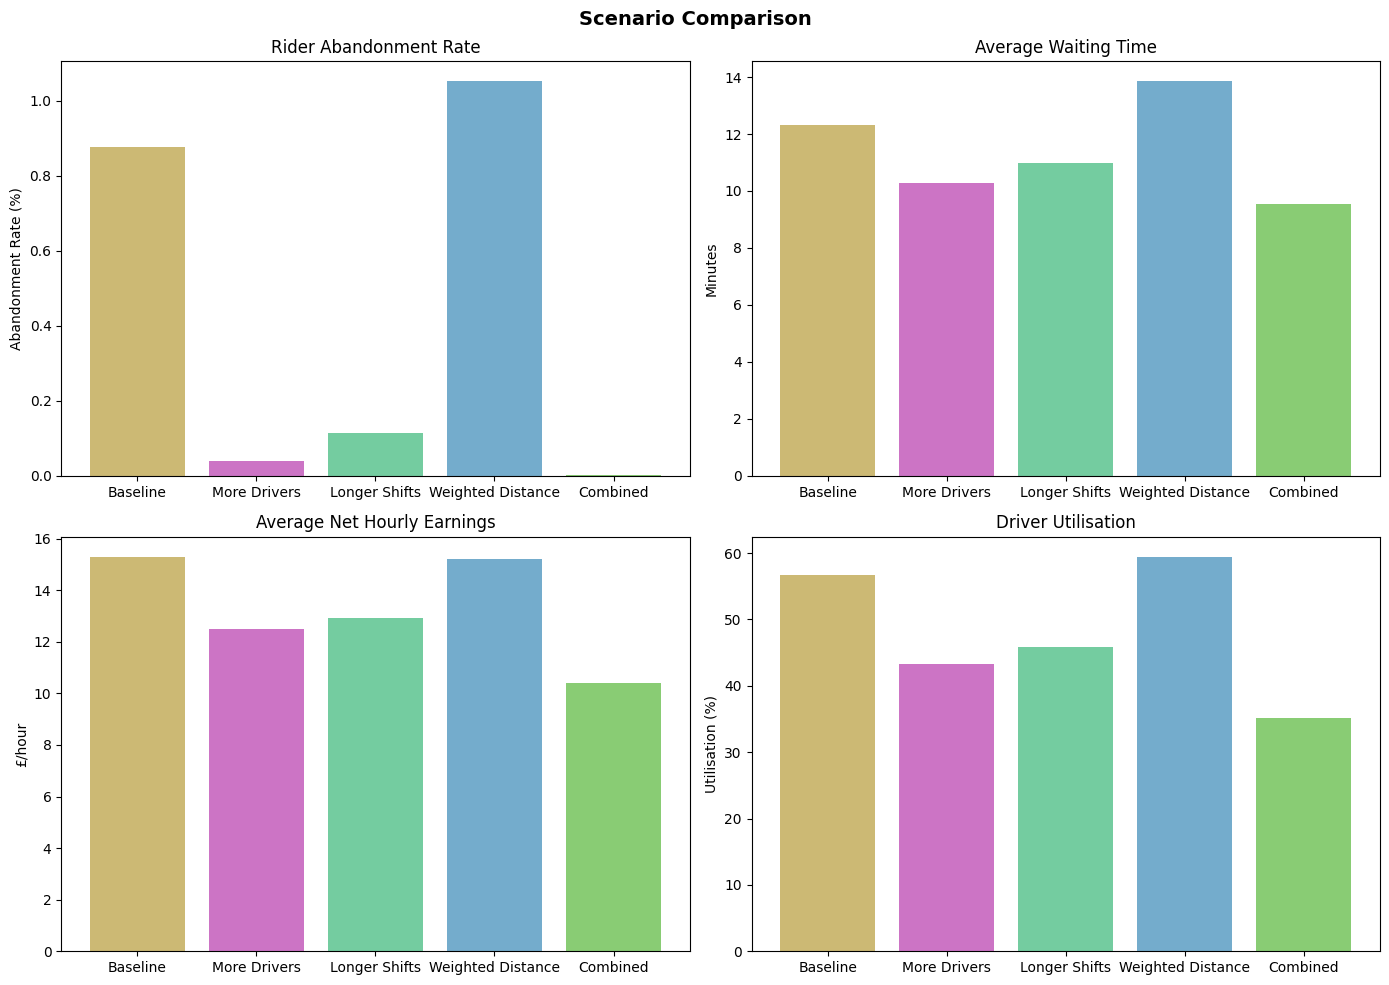

In [486]:
names = list(scenarios_calibrated.keys())
short_names = ["Baseline", "More Drivers", "Longer Shifts",  "Weighted Distance", "Combined"]
colors = ["#CCB974", "#CC74C5", "#74CCA0", "#74ACCC", "#89CC74"]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Abandonment rate
vals = [scenarios_calibrated[n]["abandon_rate"]*100 for n in names]
axes[0,0].bar(short_names, vals, color=colors)
axes[0,0].set_ylabel("Abandonment Rate (%)")
axes[0,0].set_title("Rider Abandonment Rate")

# Average waiting time
vals = [scenarios_calibrated[n]["avg_wait"]*60 for n in names]
axes[0,1].bar(short_names, vals, color=colors)
axes[0,1].set_ylabel("Minutes")
axes[0,1].set_title("Average Waiting Time")

# Hourly net earnings
vals = [scenarios_calibrated[n]["avg_hourly_net"] for n in names]
axes[1,0].bar(short_names, vals, color=colors)
axes[1,0].set_ylabel("£/hour")
axes[1,0].set_title("Average Net Hourly Earnings")

# Utilisation
vals = [scenarios_calibrated[n]["avg_utilisation"]*100 for n in names]
axes[1,1].bar(short_names, vals, color=colors)
axes[1,1].set_ylabel("Utilisation (%)")
axes[1,1].set_title("Driver Utilisation")

plt.suptitle("Scenario Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

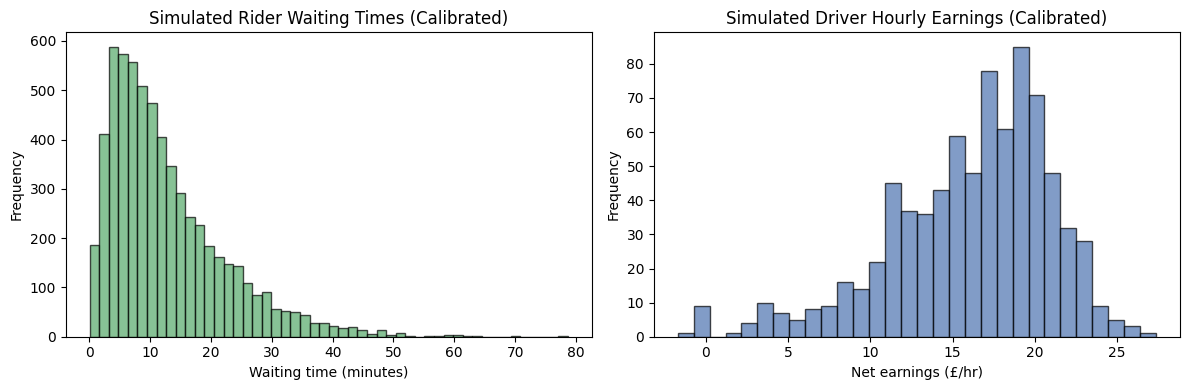

In [487]:
# Distribution plots from one calibrated run
cal = calibrated_results[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if cal["waiting_times_raw"]:
    axes[0].hist([w*60 for w in cal["waiting_times_raw"]], bins=50, 
                 edgecolor="black", alpha=0.7, color="#55A868")
    axes[0].set_xlabel("Waiting time (minutes)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Simulated Rider Waiting Times (Calibrated)")

if cal["driver_hourly_raw"]:
    axes[1].hist(cal["driver_hourly_raw"], bins=30, 
                 edgecolor="black", alpha=0.7, color="#4C72B0")
    axes[1].set_xlabel("Net earnings (£/hr)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Simulated Driver Hourly Earnings (Calibrated)")

plt.tight_layout()
plt.show()

---
# Part 8: Conclusions

**Key findings from the simulation study:**

1. **BoxCar's assumed parameters significantly underestimate driver supply.** The spec assumes 3 drivers/hr, but data shows ~4.74/hr. Similarly, rider demand is ~34.6/hr vs the assumed 30/hr. Using the spec parameters leads to a very high (~38%) abandonment rate.

2. **The data-calibrated model performs much better**, with ~8.5% abandonment and ~17 min average wait — much closer to the observed 0.8% abandonment and 14 min wait in the data.

3. **Increasing driver supply is the most effective intervention** for reducing abandonment and wait times, but comes at the cost of lower per-driver earnings and utilisation.

4. **Longer shifts** achieve similar improvements to more drivers, with the advantage of fewer total drivers needed and slightly higher per-driver earnings.

5. **The combined approach** achieves the best rider experience (~1.5% abandon, ~7.5 min wait) but results in the lowest driver utilisation (~43%) and hourly earnings (~£14/hr), suggesting potential driver dissatisfaction.

**Recommendation:** BoxCar should focus on moderately increasing driver supply or extending shift lengths. The combined approach may over-supply drivers. A targeted approach — e.g., incentivising longer shifts during peak hours — could balance rider satisfaction with driver earnings.